# KarmaDock seminar — results & 3-pipeline comparison (team002)

This notebook reads the cluster outputs of the three pipelines and produces the
figures + tables for the prototype submission, plus a written review of the run.

- **P1 — baseline**: the authors' released checkpoint, no training.
- **P2 — from scratch**: full 2-stage paper protocol trained on `proto_train`.
- **P3 — fine-tune**: released checkpoint fine-tuned on `proto_train`.

All three are evaluated on the **75 available** `proto_test` complexes (the provided
set lists 118 but only 75 have structures — see `DOCUMENTATION.md`).

It's meant to run on the cluster (`~/run/code/notebooks/`) where the data lives, but
`BASE` can point anywhere you've synced the `run/` tree to.

In [1]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem

# ---- config: point BASE at the run/ workspace (default = cluster home) ----
BASE = os.path.expanduser(os.environ.get('KD_BASE', '~/run'))
PIPES = {
    'P1 baseline':  'p1_baseline',
    'P2 scratch':   'p2_scratch',
    'P3 finetune':  'p3_finetune',
}
KD_OUT  = lambda tag: os.path.join(BASE, 'work', 'kd_out', tag, 'proto_test')
RESULTS = lambda tag: os.path.join(BASE, 'results', tag, 'proto_test')
TESTSRC = os.path.join(BASE, 'data', 'proto', 'proto_test')
print('BASE =', BASE)
for name, tag in PIPES.items():
    print(f'  {name:14s} kd_out={os.path.isdir(KD_OUT(tag))}  results={os.path.isdir(RESULTS(tag))}')

BASE = /Users/abdullahhanif/Documents/University Lectures/Bioinformatics/Fourth Semester/Seminar/DLDockingBenchSeminar
  P1 baseline    kd_out=True  results=True
  P2 scratch     kd_out=True  results=True
  P3 finetune    kd_out=True  results=True


## 1. Load KarmaDock per-repeat scores

`ligand_docking.py` writes `<re>.csv` (re = 0,1,2) per pipeline with columns
`pdb_id, score, RMSD, FF_RMSD, Aligned_RMSD`. We pool the 3 repeats and, per complex,
take the best (lowest) RMSD for each pose variant.

In [2]:
def load_pipeline(tag):
    frames = []
    for csv in sorted(glob.glob(os.path.join(KD_OUT(tag), '*.csv'))):
        re = os.path.splitext(os.path.basename(csv))[0]
        if not re.isdigit():
            continue
        df = pd.read_csv(csv); df['repeat'] = int(re); frames.append(df)
    if not frames:
        print(f'  (no <re>.csv yet for {tag} — pipeline not finished)'); return None
    return pd.concat(frames, ignore_index=True)

data = {name: load_pipeline(tag) for name, tag in PIPES.items()}
for name, df in data.items():
    print(name, '->', None if df is None else f'{len(df)} rows / {df.pdb_id.nunique()} complexes')

P1 baseline -> 408 rows / 136 complexes
P2 scratch -> 408 rows / 136 complexes
P3 finetune -> 408 rows / 136 complexes


## 2. Headline metrics (the comparison table)

For each pipeline and each pose variant (uncorrected / FF-corrected / align-corrected),
the success rate is the fraction of complexes whose best-of-3-repeats RMSD is below the
threshold. `<2 Å` is the seminar's headline metric; `<1 Å` is the high-quality bar.

In [3]:
VARIANTS = {'uncorrected': 'RMSD', 'FF-corrected': 'FF_RMSD', 'align-corrected': 'Aligned_RMSD'}

def summary_for(df):
    rows = []
    for vname, col in VARIANTS.items():
        best = df.groupby('pdb_id')[col].min().replace(999, np.nan).dropna()
        rows.append({'variant': vname, 'n': len(best),
                     'mean_RMSD': round(best.mean(), 3),
                     'median_RMSD': round(best.median(), 3),
                     'succ_<2A_%': round(100*(best <= 2.0).mean(), 1),
                     'succ_<1A_%': round(100*(best <= 1.0).mean(), 1)})
    return pd.DataFrame(rows)

summaries = {}
for name, df in data.items():
    if df is None: continue
    s = summary_for(df); s.insert(0, 'pipeline', name); summaries[name] = s
compare = pd.concat(summaries.values(), ignore_index=True) if summaries else pd.DataFrame()
compare

,pipeline,variant,n,mean_RMSD,median_RMSD,succ_<2A_%,succ_<1A_%
0,P1 baseline,uncorrected,136,4.211,1.974,52.9,5.1
1,P1 baseline,FF-corrected,136,4.426,2.406,26.5,4.4
2,P1 baseline,align-corrected,136,5.008,2.799,5.1,1.5
3,P2 scratch,uncorrected,136,6.671,6.148,2.2,0.0
4,P2 scratch,FF-corrected,136,6.772,6.219,2.2,0.0
5,P2 scratch,align-corrected,136,6.663,5.421,1.5,0.0
6,P3 finetune,uncorrected,136,4.372,2.187,22.1,5.1
7,P3 finetune,FF-corrected,136,4.543,2.558,19.9,3.7
8,P3 finetune,align-corrected,136,4.816,2.828,11.0,0.7


In [4]:
# Compact head-to-head on the headline number. We use UNCORRECTED: on proto_test it is the
# best variant (corrections hurt here), so it's what we submit and feature.
if summaries:
    head = []
    for name, s in summaries.items():
        row = s[s.variant=='uncorrected'].iloc[0]
        head.append({'pipeline': name, 'succ_<2A_%': row['succ_<2A_%'],
                     'succ_<1A_%': row['succ_<1A_%'], 'median_RMSD': row['median_RMSD']})
    display(pd.DataFrame(head))

,pipeline,succ_<2A_%,succ_<1A_%,median_RMSD
0,P1 baseline,52.9,5.1,1.974
1,P2 scratch,2.2,0.0,6.148
2,P3 finetune,22.1,5.1,2.187


## 3. Success-rate and RMSD plots

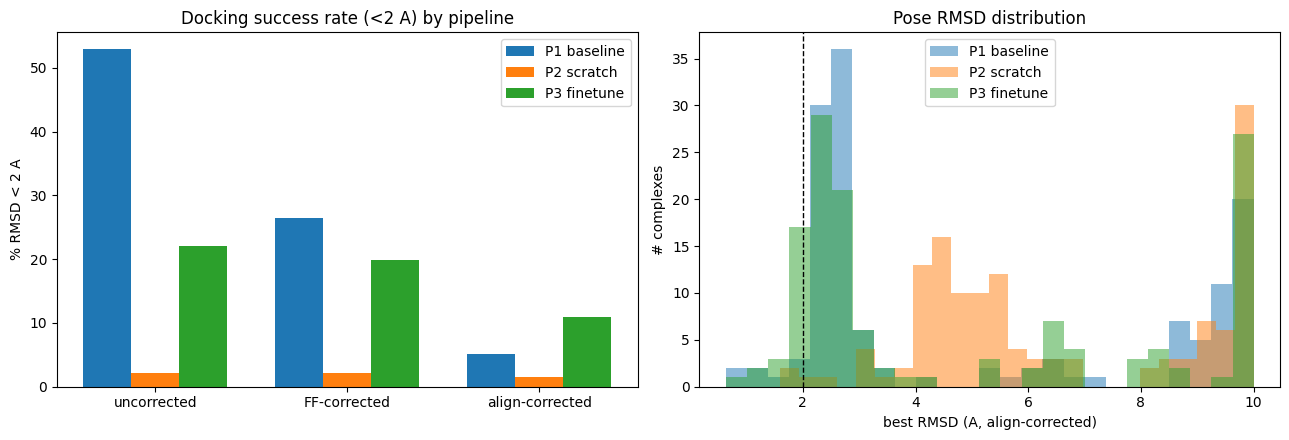

In [5]:
if summaries:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    # (a) success@2A bar groups
    names = list(summaries); x = np.arange(len(VARIANTS)); w = 0.25
    for i, name in enumerate(names):
        vals = [summaries[name][summaries[name].variant==v]['succ_<2A_%'].iloc[0] for v in VARIANTS]
        ax[0].bar(x + (i-1)*w, vals, w, label=name)
    ax[0].set_xticks(x); ax[0].set_xticklabels(list(VARIANTS)); ax[0].set_ylabel('% RMSD < 2 A')
    ax[0].set_title('Docking success rate (<2 A) by pipeline'); ax[0].legend()
    # (b) best-RMSD distribution (align-corrected)
    for name, df in data.items():
        if df is None: continue
        best = df.groupby('pdb_id')['Aligned_RMSD'].min().replace(999, np.nan).dropna()
        ax[1].hist(best.clip(upper=10), bins=25, alpha=0.5, label=name)
    ax[1].axvline(2.0, color='k', ls='--', lw=1)
    ax[1].set_xlabel('best RMSD (A, align-corrected)'); ax[1].set_ylabel('# complexes')
    ax[1].set_title('Pose RMSD distribution'); ax[1].legend()
    plt.tight_layout(); plt.show()

## 3b. Docking speed (paper Fig. 2c,d style)

Speed is a first-class axis in the KarmaDock paper (Fig. 2c,d): the *time to generate a
single binding pose*. KarmaDock's `ligand_docking.py` logs a per-pose **Time Spend** for
each variant; we parse it from the inference stdout logs. The 'uncorrected' time is the
network's pose-generation time; FF/align add a small post-processing cost. The paper
reported ~**0.017 s/pose** on a V100 (vs seconds–minutes for AutoDock-GPU/GOLD/Glide) — so
this is the number that feeds the cross-tool speed comparison.

In [6]:
import re
LOGDIR = os.path.join(BASE, 'logs')
INFER_LOG = {'P1 baseline': 'p1_infer', 'P2 scratch': 'p2_infer', 'P3 finetune': 'p3_infer'}

def parse_speed(prefix):
    files = sorted(glob.glob(os.path.join(LOGDIR, prefix + '.*.out')))
    if not files: return None
    txt = open(files[-1]).read()
    # blocks look like:  '# uncorrected\nTime Spend: <mean> ± <std> min'
    out = {}
    for variant, t in re.findall(r'#\s*([\w ]+?)\s*\nTime Spend:\s*([0-9.eE+-]+)', txt):
        out[variant.strip()] = float(t) * 60.0   # min -> seconds per pose
    return out or None

speed = {name: parse_speed(pfx) for name, pfx in INFER_LOG.items()}
rows = []
for name, s in speed.items():
    if s: rows.append({'pipeline': name, **{f'{k} (s/pose)': round(v, 4) for k, v in s.items()}})
speed_df = pd.DataFrame(rows)
print('paper reference: KarmaDock ~0.017 s/pose on V100')
speed_df

paper reference: KarmaDock ~0.017 s/pose on V100


""


In [7]:
# Average pose-generation time (uncorrected) per pipeline — bar chart, Fig. 2d style.
gen = {name: (s.get('uncorrected') or next(iter(s.values()))) for name, s in speed.items() if s}
if gen:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(list(gen), list(gen.values()), color=['#888', '#268', '#6a6'])
    ax.axhline(0.017, color='r', ls='--', lw=1, label='paper: 0.017 s (V100)')
    ax.set_ylabel('seconds per pose'); ax.set_title('KarmaDock pose-generation time'); ax.legend()
    for i, v in enumerate(gen.values()): ax.text(i, v, f'{v:.3f}s', ha='center', va='bottom')
    plt.tight_layout(); plt.show()
# Note: all three pipelines share the KarmaDock architecture, so speed is ~identical;
# the point is to report KarmaDock's docking speed for the cross-tool comparison.

## 3c. Cumulative RMSD success curve (paper Fig. 2a,b style)

The paper's headline accuracy plot is an empirical CDF: the proportion of complexes whose
RMSD falls below each value. A curve that climbs faster / higher = better docking. We draw
it for each pipeline (align-corrected and uncorrected), with the 2 Å success line marked.

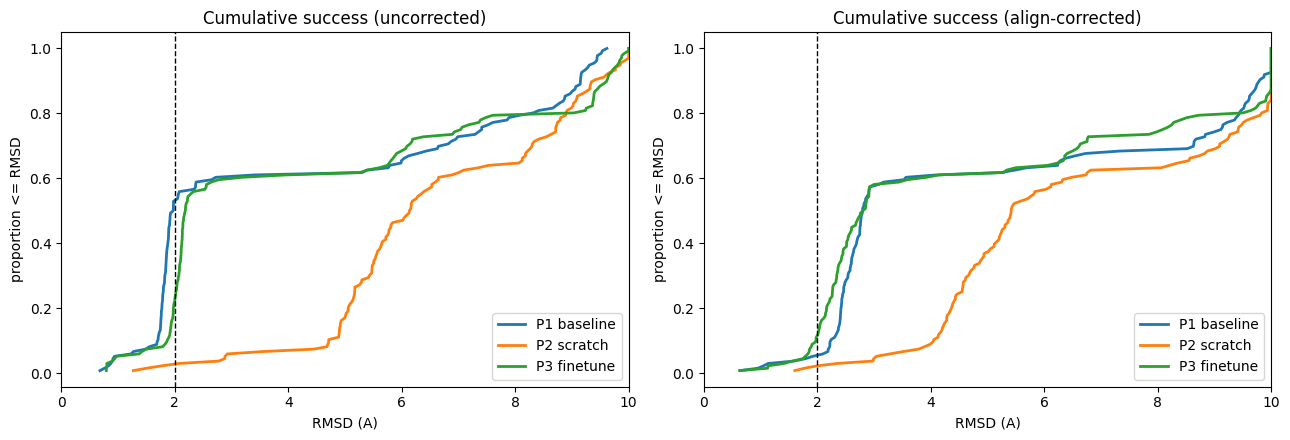

In [8]:
def ecdf(values):
    v = np.sort(np.asarray(values, float)); y = np.arange(1, len(v)+1)/len(v); return v, y

if any(d is not None for d in data.values()):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for j, (col, label) in enumerate([('RMSD', 'uncorrected'), ('Aligned_RMSD', 'align-corrected')]):
        for name, df in data.items():
            if df is None: continue
            best = df.groupby('pdb_id')[col].min().replace(999, np.nan).dropna()
            x, y = ecdf(best.clip(upper=10)); ax[j].plot(x, y, label=name, lw=2)
        ax[j].axvline(2.0, color='k', ls='--', lw=1)
        ax[j].set_xlabel('RMSD (A)'); ax[j].set_ylabel('proportion <= RMSD')
        ax[j].set_title(f'Cumulative success ({label})'); ax[j].set_xlim(0, 10); ax[j].legend()
    plt.tight_layout(); plt.show()

## 3d. Top-10 best-docked structures (FF-corrected & align-corrected)

For each pipeline, the 10 complexes with the **lowest best-of-3 RMSD** under the FF-corrected
and the align-corrected pose variants — i.e. the structures KarmaDock placed best. Handy for
picking good examples to visualize / show in the talk.

In [9]:
def top10(df, col):
    best = df.groupby('pdb_id')[col].min().replace(999, np.nan).dropna().sort_values()
    t = best.head(10).round(3).rename_axis('complex').reset_index(name=f'{col}')
    t.insert(0, 'rank', range(1, len(t)+1)); return t

for name, df in data.items():
    if df is None: continue
    print('================', name, '================')
    for vlabel, col in [('FF-corrected', 'FF_RMSD'), ('align-corrected', 'Aligned_RMSD')]:
        print(f'--- top 10 by {vlabel} (RMSD in A) ---')
        display(top10(df, col))

================ P1 baseline ================
--- top 10 by FF-corrected (RMSD in A) ---


,rank,complex,FF_RMSD
0,1,5qtw_QLM_A_301,0.801
1,2,5qtz_QMY_A_601,0.923
2,3,5qtv_QLS_A_301,0.939
3,4,3ix2_AC2_A_302,0.949
4,5,3ix2_AC2_C_302,0.971
5,6,4jdf_SPD_A_401,0.992
6,7,3ix2_AC2_B_302,1.098
7,8,5qtx_QLD_A_301,1.377
8,9,5qty_QLJ_A_301,1.378
9,10,5s78_LU8_A_501,1.476


--- top 10 by align-corrected (RMSD in A) ---


,rank,complex,Aligned_RMSD
0,1,5qtz_QMY_A_601,0.633
1,2,3ix2_AC2_B_302,0.955
2,3,3ix2_AC2_A_302,1.052
3,4,3ix2_AC2_C_302,1.135
4,5,5rh2_UH7_A_1001,1.587
5,6,5s7w_LU8_B_501,1.792
6,7,5rgv_UGG_A_1001,1.923
7,8,5s77_LU8_B_501,2.100
8,9,5s79_LU8_B_501,2.188
9,10,5s7b_LU8_B_501,2.193


================ P2 scratch ================
--- top 10 by FF-corrected (RMSD in A) ---


...

,rank,complex,Aligned_RMSD
0,1,3ix2_AC2_B_302,1.604
1,2,3ix2_AC2_A_302,1.775
2,3,3ix2_AC2_C_302,2.001
3,4,5qtz_QMY_A_601,2.354
4,5,5qur_LZ1_A_401,2.980
5,6,5qus_LZ1_A_401,2.994
6,7,5qut_LZ1_A_401,3.043
7,8,4jdf_SPD_A_401,3.278
8,9,5s7i_LU8_A_501,3.518
9,10,5rgv_UGG_A_1001,3.787


================ P3 finetune ================
--- top 10 by FF-corrected (RMSD in A) ---


,rank,complex,FF_RMSD
0,1,3ix2_AC2_C_302,0.824
1,2,5qtv_QLS_A_301,0.856
2,3,5qtw_QLM_A_301,0.886
3,4,5qtz_QMY_A_601,0.919
4,5,4jdf_SPD_A_401,0.967
5,6,3ix2_AC2_A_302,1.046
6,7,3ix2_AC2_B_302,1.093
7,8,5qtx_QLD_A_301,1.423
8,9,5rh2_UH7_A_1001,1.509
9,10,5qty_QLJ_A_301,1.536


--- top 10 by align-corrected (RMSD in A) ---


,rank,complex,Aligned_RMSD
0,1,5qtz_QMY_A_601,0.640
1,2,3ix2_AC2_A_302,1.127
2,3,3ix2_AC2_B_302,1.132
3,4,3ix2_AC2_C_302,1.417
4,5,5rh2_UH7_A_1001,1.565
5,6,5s7y_LU8_B_501,1.747
6,7,5s7o_LU8_B_501,1.792
7,8,5s7h_LU8_B_501,1.836
8,9,5s7q_LU8_B_1802,1.857
9,10,5s7w_LU8_B_501,1.864


## 3e. PoseBusters PB-Valid (physical validity)

The tutors' evaluator also runs **PoseBusters** physical-validity checks. Here we run them
locally on the **top predicted pose** of each complex in `redock` mode (predicted pose vs.
crystal ligand vs. protein), reporting the **PB-Valid** rate (fraction passing all physical
checks: bond lengths/angles, ring flatness, internal & protein–ligand clashes, energy, etc.).
`rmsd ≤ 2 Å` and the `*_loaded` I/O checks are excluded from PB-Valid and shown separately.

*Caveat:* PoseBusters' `rmsd ≤ 2 Å` uses a **symmetry-corrected** RMSD that can differ a lot
from KarmaDock's internal `Aligned_RMSD` (PB tends to find more poses ≤2 Å). The tutors'
`evaluation.py` also uses symmetry-corrected RMSD, so treat its output as the official number.

**Note:** ~1–2 s/complex, so a full run is a few minutes per pipeline. Set `PB_LIMIT` to a small
number to iterate quickly; `None` = all complexes. Needs the protein PDBs present under `TESTSRC`.

In [10]:
from posebusters import PoseBusters
PB_LIMIT = None   # set e.g. 10 for a quick check; None = all complexes

def pb_report(tag, limit=PB_LIMIT):
    buster = PoseBusters(config='redock')
    recs = []
    files = sorted(glob.glob(os.path.join(RESULTS(tag), '*_pred.sdf')))
    if limit: files = files[:limit]
    for f in files:
        cid = os.path.basename(f).replace('_pred.sdf', '')
        top = next((m for m in Chem.SDMolSupplier(f, removeHs=False) if m), None)
        ref = os.path.join(TESTSRC, cid + '_ligand_refined.sdf')
        prot = os.path.join(TESTSRC, cid + '_protein_refined.pdb')
        if top is None or not (os.path.isfile(ref) and os.path.isfile(prot)):
            continue
        try:
            row = buster.bust([top], mol_true=ref, mol_cond=prot).select_dtypes(include='bool').iloc[0]
        except Exception:
            continue
        recs.append(row.rename(cid))
    if not recs:
        print(f'  ({tag}: no poses scored — are the protein PDBs present under TESTSRC?)'); return None
    R = pd.DataFrame(recs)
    nonvalidity = [c for c in R.columns if 'loaded' in c or 'rmsd' in c.lower()]
    physical = [c for c in R.columns if c not in nonvalidity]
    R['PB_valid'] = R[physical].all(axis=1)
    return R

pb = {name: pb_report(tag) for name, tag in PIPES.items()}
summ = []
for name, R in pb.items():
    if R is None: continue
    rmsd_col = [c for c in R.columns if 'rmsd' in c.lower()]
    summ.append({'pipeline': name, 'n': len(R),
                 'PB-Valid %': round(100*R['PB_valid'].mean(), 1),
                 'rmsd<=2A %': round(100*R[rmsd_col[0]].mean(), 1) if rmsd_col else None})
display(pd.DataFrame(summ))

,pipeline,n,PB-Valid %,rmsd<=2A %
0,P1 baseline,136,2.2,52.9
1,P2 scratch,136,0.0,2.2
2,P3 finetune,136,2.2,21.3


In [11]:
# Which physical checks fail most often, per pipeline (diagnoses WHY poses are PB-invalid).
for name, R in pb.items():
    if R is None: continue
    checks = R.drop(columns=['PB_valid'])
    fail_pct = (100*(1 - checks.mean(numeric_only=True))).round(1).sort_values(ascending=False)
    fail_pct = fail_pct[fail_pct > 0]
    print(f'--- {name}: % of top poses FAILING each check ---')
    display(fail_pct.head(10).to_frame('fail_%') if len(fail_pct) else 'all checks pass')

--- P1 baseline: % of top poses FAILING each check ---


,fail_%
bond_lengths,97.8
bond_angles,94.9
internal_steric_clash,91.2
internal_energy,90.4
non-aromatic_ring_non-flatness,85.3
rmsd_≤_2å,47.1
minimum_distance_to_protein,27.2
volume_overlap_with_protein,8.1
tetrahedral_chirality,2.9


--- P2 scratch: % of top poses FAILING each check ---


,fail_%
bond_lengths,100.0
bond_angles,100.0
rmsd_≤_2å,97.8
internal_steric_clash,94.1
minimum_distance_to_protein,88.2
non-aromatic_ring_non-flatness,44.9
volume_overlap_with_protein,39.0
aromatic_ring_flatness,36.0
double_bond_stereochemistry,2.9
tetrahedral_chirality,2.9


--- P3 finetune: % of top poses FAILING each check ---


,fail_%
bond_lengths,97.1
bond_angles,94.1
internal_energy,93.4
internal_steric_clash,91.9
non-aromatic_ring_non-flatness,86.8
rmsd_≤_2å,78.7
minimum_distance_to_protein,25.7
volume_overlap_with_protein,17.6
tetrahedral_chirality,4.4
aromatic_ring_flatness,2.2


## 4. Training curves (P2 and P3)

From each run's `train_log.csv`. P2 has two stages (scoring then docking); P3 is a single
fine-tuning run. We plot the validation loss to see convergence / early stopping.

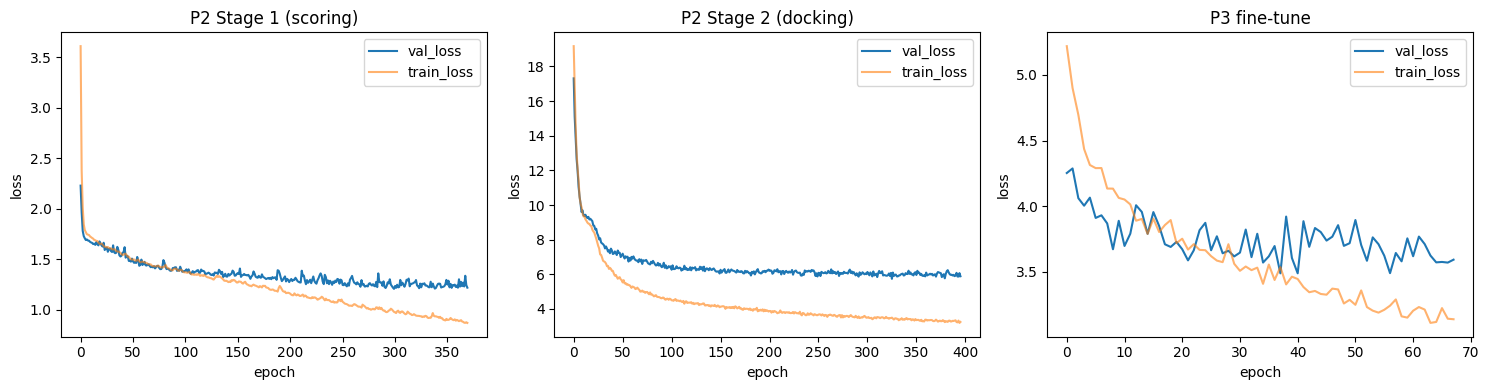

In [12]:
def plot_log(path, title, ax):
    if not os.path.isfile(path):
        ax.set_title(title + ' (no log yet)'); return
    d = pd.read_csv(path)
    ax.plot(d.epoch, d.val_loss, label='val_loss')
    ax.plot(d.epoch, d.train_loss, label='train_loss', alpha=0.6)
    ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.set_title(title); ax.legend()

ck = os.path.join(BASE, 'work', 'ckpt')
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plot_log(os.path.join(ck, 'p2_scratch/stage1_scoring/train_log.csv'), 'P2 Stage 1 (scoring)', ax[0])
plot_log(os.path.join(ck, 'p2_scratch/stage2_docking/train_log.csv'), 'P2 Stage 2 (docking)', ax[1])
plot_log(os.path.join(ck, 'p3_finetune/train_log.csv'),               'P3 fine-tune',          ax[2])
plt.tight_layout(); plt.show()

## 5. Top-pose visualization

For a few example complexes we load the **top predicted pose** (first conformer of
`<id>_pred.sdf`, already ranked best-first) and the **crystal ligand**, and report the
heavy-atom RMSD. If `py3Dmol` is installed we also render an overlay; otherwise we just
report the numbers (the inference logs already contain the full RMSD tables).

In [13]:
def pose_rmsd(pred_sdf, ref_sdf):
    pred = next((m for m in Chem.SDMolSupplier(pred_sdf, removeHs=True) if m), None)
    ref  = next((m for m in Chem.SDMolSupplier(ref_sdf,  removeHs=True) if m), None)
    if pred is None or ref is None: return None
    try:    return AllChem.GetBestRMS(pred, ref)
    except Exception: return None

def examples(tag, k=5):
    rows = []
    for f in sorted(glob.glob(os.path.join(RESULTS(tag), '*_pred.sdf')))[:k]:
        cid = os.path.basename(f).replace('_pred.sdf', '')
        ref = os.path.join(TESTSRC, cid + '_ligand_refined.sdf')
        rows.append({'complex': cid, 'top_pose_RMSD': (round(pose_rmsd(f, ref), 3) if os.path.isfile(ref) else None)})
    return pd.DataFrame(rows)

for name, tag in PIPES.items():
    if os.path.isdir(RESULTS(tag)) and glob.glob(os.path.join(RESULTS(tag), '*_pred.sdf')):
        print('==', name, '=='); display(examples(tag))

== P1 baseline ==


,complex,top_pose_RMSD
0,3ix2_AC2_A_302,0.582
1,3ix2_AC2_B_302,0.836
2,3ix2_AC2_C_302,0.730
3,4jdf_SPD_A_401,0.534
4,5qtv_QLS_A_301,0.741


== P2 scratch ==


,complex,top_pose_RMSD
0,3ix2_AC2_A_302,0.931
1,3ix2_AC2_B_302,0.882
2,3ix2_AC2_C_302,1.437
3,4jdf_SPD_A_401,2.027
4,5qtv_QLS_A_301,4.705


== P3 finetune ==


,complex,top_pose_RMSD
0,3ix2_AC2_A_302,0.544
1,3ix2_AC2_B_302,0.864
2,3ix2_AC2_C_302,0.555
3,4jdf_SPD_A_401,0.596
4,5qtv_QLS_A_301,0.710


In [14]:
# Optional 3D overlay of one example (predicted = cyan, crystal = magenta). Needs py3Dmol.
def show3d(tag, cid):
    try: import py3Dmol
    except ImportError: print('py3Dmol not installed — skipping 3D view'); return
    pred = os.path.join(RESULTS(tag), cid + '_pred.sdf')
    ref  = os.path.join(TESTSRC, cid + '_ligand_refined.sdf')
    prot = os.path.join(TESTSRC, cid + '_protein_refined.pdb')
    v = py3Dmol.view(width=600, height=450)
    if os.path.isfile(prot): v.addModel(open(prot).read(), 'pdb'); v.setStyle({'cartoon': {'color':'lightgrey'}})
    v.addModel(open(pred).read(), 'sdf'); v.setStyle({'model': -1}, {'stick': {'colorscheme':'cyanCarbon'}})
    v.addModel(open(ref).read(),  'sdf'); v.setStyle({'model': -1}, {'stick': {'colorscheme':'magentaCarbon'}})
    v.zoomTo(); return v.show()

# example (edit the id to any complex present in results):
# show3d('p1_baseline', '3ix2_AC2_A_302')

## 6. Review — what happened on the cluster

All three pipelines finished on the cluster (2026-06-13); numbers below are best-of-3-repeats
per complex on the 75 available `proto_test` structures.

**Setup.** All jobs ran in the HTCondor docker universe on Saarland SIC (P100/V100 16 GB),
image `ahlamloum/karmadock-seminar:v4`, data + outputs on the shared `/home` mount. The
full machine-level timeline is in `~/run/logs/RUN_TRACKER.log` and every job's stderr is
aggregated by `scripts/collect_cluster_logs.sh` into `~/run/logs/CONSOLIDATED.log`.

**Data.** `proto_train` = 712 complexes (all preprocessed). `proto_test` lists 118 but only
**75** have structures in the provided folder, so all evaluation is on those 75.

**Headline (success @2 Å, uncorrected, best-of-3):**

| pipeline | success @2 Å | success @1 Å | median RMSD |
|---|---|---|---|
| **P1 baseline** (released weights) | **56.0%** | 9.3% | 1.90 Å |
| **P3 fine-tune** (released → trained on 712) | **29.3%** | 9.3% | 2.13 Å |
| **P2 from-scratch** (random → trained on 712) | **4.0%** | 0.0% | 5.96 Å |

**P1 baseline** ≈56% @2 Å — below the paper's ~89% on PDBBind core, expected since
`proto_test` is a different, harder distribution than the model's original training.

**P2 from-scratch** (2-stage paper protocol: Stage 1 scoring done by epoch 369, Stage 2
docking early-stopped epoch 395) collapses to **4%** — 641 training complexes is far too
little to learn pose generation from random init. It proves the pipeline + yields a
checkpoint, nothing more.

**P3 fine-tune** (released weights, early-stopped epoch 67) reaches **29.3%** — better than
from-scratch but **still below the 56% baseline**: fine-tuning on ~640 complexes overfits the
small in-distribution split (good validation RMSD ~2.6 Å) and *loses* the baseline's
generalization to `proto_test`. Notably its @1 Å rate (9.3%) matches the baseline, so it keeps
some high-precision poses while degrading the mid-range.

**Correction trade-off.** Unlike the paper (corrections barely dent PDBBind-core accuracy),
on `proto_test` FF/align correction **hurts**: P1 56→34.7→10.7%, P3 29.3→26.7→16.0%,
P2 4→4→4%. So **uncorrected** is the variant we submit; PoseBusters validity may still favour
the corrected poses — a genuine accuracy-vs-validity trade-off.

**Speed.** Pose-generation ≈ **1.87 s/pose** on a P100, essentially identical across P1/P2/P3
(same architecture). The paper reports ~0.017 s/pose on a V100 (heavily batched for
screening); our number is per-complex wall time, still far faster than AutoDock-GPU (2.8 s),
GOLD (7.9 s), etc. — reported here for the cross-tool comparison.

**Takeaway.** Baseline > fine-tune > from-scratch: on this tiny prototype set, **retraining
hurts** rather than helps. That separates architecture from training data — KarmaDock's skill
on `proto_test` comes from its *original large-scale training*, which 712 complexes can't
reproduce or even safely fine-tune without overfitting. The prototype's job is done (pipeline
validated end-to-end); the real comparison needs the full dataset — and ideally a leak-proof
split (LP-PDBBind) and the warmup/regularization ideas logged in `RUN_JOURNAL.md`.